In [ ]:
pimport time
startime=time.time()

In [ ]:
!pip install openpyxl
# !pip install fireducks

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.9/250.9 kB 5.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import openpyxl
# import fireducks.pandas as pd
from matplotlib import pyplot as plt

In [ ]:
!wget https://archive.ics.uci.edu/static/public/352/online+retail.zip


--2025-09-20 18:22:27--  https://archive.ics.uci.edu/static/public/352/online+retail.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘online+retail.zip’

online+retail.zip       [    <=>             ]  22.62M  29.7MB/s    in 0.8s    

2025-09-20 18:22:29 (29.7 MB/s) - ‘online+retail.zip’ saved [23715478]



In [ ]:
!unzip /content/online+retail.zip

Archive:  /content/online+retail.zip
 extracting: Online Retail.xlsx      


In [ ]:
df1 = pd.read_excel("Online Retail.xlsx", dtype={'InvoiceNo': 'string', 'StockCode': 'string', 'Description': 'string', 'Country': 'string'})
df1.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [ ]:
df1.shape

(541909, 8)

In [ ]:
df1.size

4335272

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  string        
 1   StockCode    541909 non-null  string        
 2   Description  540455 non-null  string        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  string        
dtypes: datetime64[ns](1), float64(2), int64(1), string(4)
memory usage: 33.1 MB


#### Data cleaning - Handling Missing values

In [ ]:
df1.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df1[df1.Description.isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,<NA>,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,<NA>,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,<NA>,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,<NA>,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,<NA>,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,<NA>,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,<NA>,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,<NA>,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,<NA>,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [ ]:
df1[df1.StockCode=="22139"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
106,536381,22139,RETROSPOT TEA SET CERAMIC 11 PC,23,2010-12-01 09:41:00,4.25,15311.0,United Kingdom
622,536414,22139,<NA>,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
6392,536942,22139,amazon,15,2010-12-03 12:08:00,0.00,NaN,United Kingdom
6885,536982,22139,RETROSPOT TEA SET CERAMIC 11 PC,10,2010-12-03 14:27:00,11.02,NaN,United Kingdom
7203,537011,22139,<NA>,-5,2010-12-03 15:38:00,0.00,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
538411,581405,22139,RETROSPOT TEA SET CERAMIC 11 PC,1,2011-12-08 13:50:00,4.95,13521.0,United Kingdom
539531,581439,22139,RETROSPOT TEA SET CERAMIC 11 PC,1,2011-12-08 16:30:00,10.79,NaN,United Kingdom
540441,581486,22139,RETROSPOT TEA SET CERAMIC 11 PC,6,2011-12-09 09:38:00,4.95,17001.0,United Kingdom
541387,581498,22139,RETROSPOT TEA SET CERAMIC 11 PC,2,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [ ]:
df1[df1.StockCode=="22139"].Description.mode()

,Description
0,RETROSPOT TEA SET CERAMIC 11 PC


In [ ]:
Most_Freq= df1[["StockCode","Description"]].value_counts().reset_index()
Most_Freq

,StockCode,Description,count
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2302
1,22423,REGENCY CAKESTAND 3 TIER,2200
2,85099B,JUMBO BAG RED RETROSPOT,2159
3,47566,PARTY BUNTING,1727
4,20725,LUNCH BAG RED RETROSPOT,1638
...,...,...,...
4787,35833P,check,1
4788,21410,COUNTRY COTTAGE DOORSTOP GREEN,1
4789,21412,VINTAGE GOLD TINSEL REEL,1
4790,21414,SCALLOP SHELL SOAP DISH,1


In [ ]:
Most_Freq[Most_Freq.StockCode=="85123A"]

,StockCode,Description,count
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2302
3300,85123A,CREAM HANGING HEART T-LIGHT HOLDER,9
4620,85123A,wrongly marked carton 22804,1
4658,85123A,?,1


In [ ]:
Most_Freq=Most_Freq.groupby("StockCode").head(1)
Most_Freq

,StockCode,Description,count
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2302
1,22423,REGENCY CAKESTAND 3 TIER,2200
2,85099B,JUMBO BAG RED RETROSPOT,2159
3,47566,PARTY BUNTING,1727
4,20725,LUNCH BAG RED RETROSPOT,1638
...,...,...,...
4784,35832,WOOLLY HAT SOCK GLOVE ADVENT STRING,1
4785,35833G,4 GOLD FLOCK CHRISTMAS BALLS,1
4788,21410,COUNTRY COTTAGE DOORSTOP GREEN,1
4789,21412,VINTAGE GOLD TINSEL REEL,1


In [ ]:
Most_Freq.columns=["StockCode","Freq_Des","count"]

df2=df1.merge(Most_Freq, on="StockCode", how="left")
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Freq_Des,count
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,2302.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,WHITE METAL LANTERN,328.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER,293.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE,473.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.,449.0


In [ ]:
df2.Description=df2.Freq_Des
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Freq_Des,count
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,2302.0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,WHITE METAL LANTERN,328.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER,293.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE,473.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.,449.0


In [ ]:
df2.isnull().sum()  #The 112 indicates that there are some codes which doesnt have descriptions

,0
InvoiceNo,0
StockCode,0
Description,112
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0
Freq_Des,112
count,112


In [ ]:
df2.dropna(subset=["Description"], inplace=True)
df2.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,134968
Country,0
Freq_Des,0
count,0


In [ ]:
df2.drop(columns=["Freq_Des","count"], inplace=True)
df2.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df2[df2.Quantity>df2.Quantity.quantile(0.999)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
730,536437,17021,NAMASTE SWAGAT INCENSE,600,2010-12-01 12:12:00,0.24,13694.0,United Kingdom
870,536477,21137,BLACK RECORD COVER FRAME,480,2010-12-01 12:27:00,3.39,16210.0,United Kingdom
3917,536736,22616,PACK OF 12 LONDON TISSUES,600,2010-12-02 12:59:00,0.29,17381.0,United Kingdom
4850,536809,84950,ASSORTED COLOUR T-LIGHT HOLDER,1824,2010-12-02 16:48:00,0.55,15299.0,United Kingdom
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,2010-12-02 17:38:00,0.18,16754.0,United Kingdom
...,...,...,...,...,...,...,...,...
537883,581375,21137,BLACK RECORD COVER FRAME,960,2011-12-08 12:36:00,3.39,16210.0,United Kingdom
540061,581457,23543,WALL ART KEEP CALM,698,2011-12-08 18:43:00,4.15,18102.0,United Kingdom
540070,581458,22197,POPCORN HOLDER,1500,2011-12-08 18:45:00,0.72,17949.0,United Kingdom
540071,581459,22197,POPCORN HOLDER,1200,2011-12-08 18:46:00,0.72,17949.0,United Kingdom


In [ ]:
df2.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541797.000000,541797,541797.000000,406829.000000
mean,9.555919,2011-07-04 14:06:48.671255296,4.612067,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:36:00,1.250000,13953.000000
50%,3.000000,2011-07-20 08:59:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:41:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.103428,NaN,96.769831,1713.600303


In [ ]:
df2[df2.Quantity<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [ ]:
df2[(df2.CustomerID==14397.0) & (df2.Quantity<0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
341324,C566752,23130,MISTLETOE HEART WREATH GREEN,-1,2011-09-14 15:46:00,4.15,14397.0,United Kingdom
363318,C568559,20956,PORCELAIN T-LIGHT HOLDERS ASSORTED,-2,2011-09-27 16:37:00,1.25,14397.0,United Kingdom
497258,C578355,22178,VICTORIAN GLASS HANGING T-LIGHT,-3,2011-11-24 10:13:00,1.95,14397.0,United Kingdom
497259,C578355,84946,ANTIQUE SILVER T-LIGHT GLASS,-2,2011-11-24 10:13:00,1.25,14397.0,United Kingdom
497260,C578355,22596,CHRISTMAS STAR WISH LIST CHALKBOARD,-4,2011-11-24 10:13:00,1.25,14397.0,United Kingdom
497261,C578355,20956,PORCELAIN T-LIGHT HOLDERS ASSORTED,-3,2011-11-24 10:13:00,1.25,14397.0,United Kingdom
540448,C581490,22178,VICTORIAN GLASS HANGING T-LIGHT,-12,2011-12-09 09:57:00,1.95,14397.0,United Kingdom
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom


In [ ]:
df2[df2.Quantity<0].count()
# df2.count()

,0
InvoiceNo,10527
StockCode,10527
Description,10527
Quantity,10527
InvoiceDate,10527
UnitPrice,10527
CustomerID,8905
Country,10527


In [ ]:
df3=df2[(df2.UnitPrice>0) & (df2.Quantity>0)]
df3.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,530104.000000,530104,530104.000000,397884.000000
mean,10.542037,2011-07-04 20:16:05.225087744,3.907625,15294.423453
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000
25%,1.000000,2011-03-28 12:22:00,1.250000,13969.000000
50%,3.000000,2011-07-20 12:58:00,2.080000,15159.000000
75%,10.000000,2011-10-19 12:39:00,4.130000,16795.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,155.524124,NaN,35.915681,1713.141560


### Feature engineering - Creating new columns

In [ ]:
df3.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [ ]:
# df3.drop(columns="Total_Sales")

In [ ]:
df4=df3.copy()

In [ ]:
df4["Total_Sales"]=df3.UnitPrice*df3.Quantity
df4.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [ ]:
df4.tail(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Sales
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


In [ ]:
df4.shape

(530104, 9)

In [ ]:
df4["Month"]=df4.InvoiceDate.dt.month
df4

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Sales,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12


## Data Visualization and EDA

1) Plot Monthly Sales

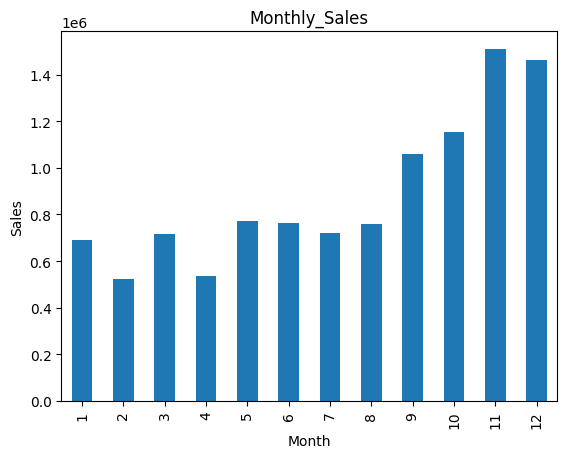

In [ ]:
# MonthWise_Sales= df4.groupby("Month") # ---> This just creates a DataFrameGroupBy Obj
# MonthWise_Sales.head(3) # This takes the 3 first 3 values of a month and prints the 36values

MonthWise_Sales=df4.groupby("Month")["Total_Sales"].sum()

MonthWise_Sales.plot(kind="bar",title="Monthly_Sales",xlabel="Month",ylabel="Sales")
plt.show()

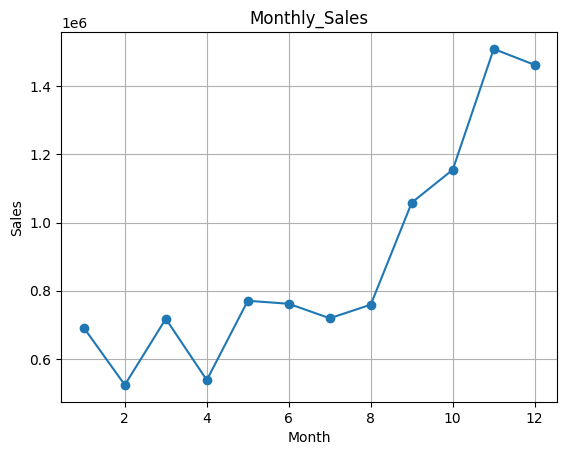

In [ ]:
MonthWise_Sales.plot(kind="line",marker="o",title="Monthly_Sales",xlabel="Month",ylabel="Sales")
plt.grid()
plt.show()

Insights

#### Total Sales started to see an upward trend from the month of august, peaking in november indicating possibility of year end sale

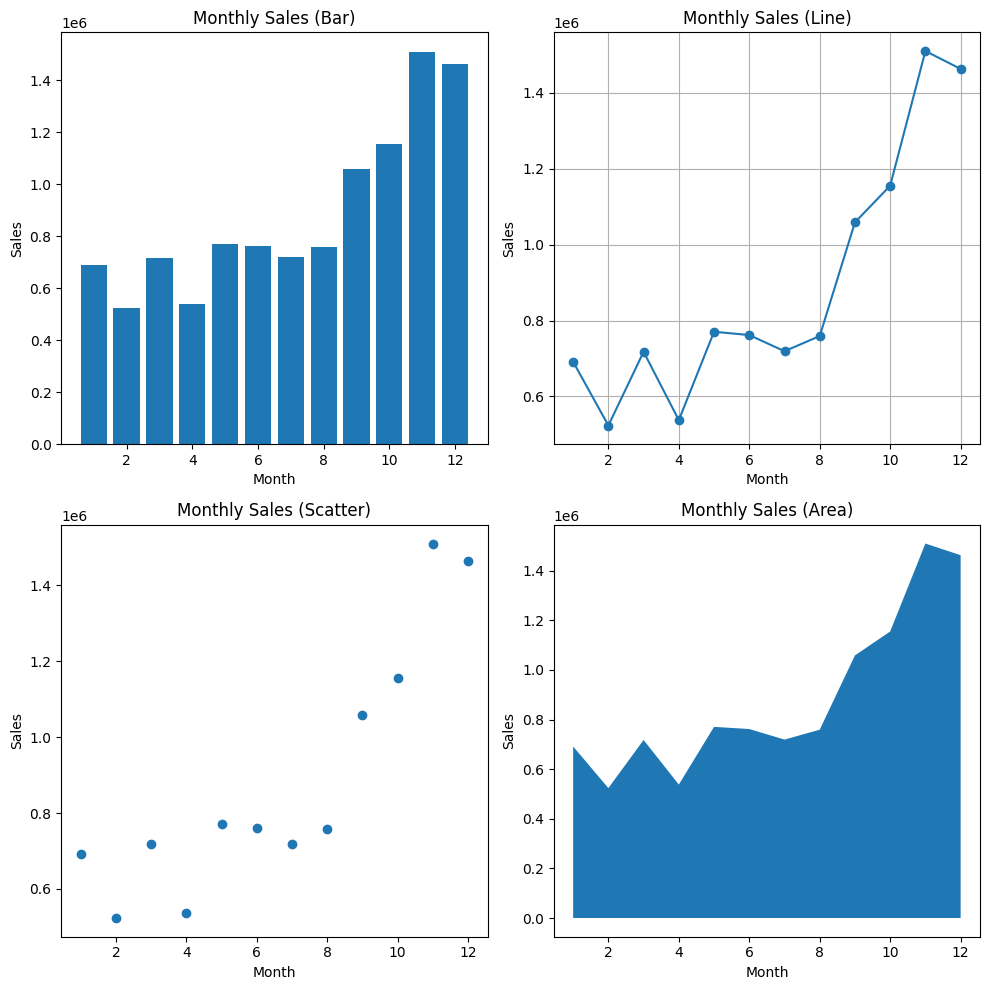

In [ ]:
x=MonthWise_Sales.index
y=MonthWise_Sales.values
fig,ax=plt.subplots(ncols=2,nrows=2,figsize=(10,10))

# Bar plot
ax[0,0].bar(x,y)
ax[0,0].set_title("Monthly Sales (Bar)")
ax[0,0].set_xlabel("Month")
ax[0,0].set_ylabel("Sales")

# Line plot
ax[0,1].plot(x,y, marker="o")
ax[0,1].set_title("Monthly Sales (Line)")
ax[0,1].set_xlabel("Month")
ax[0,1].set_ylabel("Sales")
ax[0,1].grid()

# Scatter plot
ax[1,0].scatter(x,y)
ax[1,0].set_title("Monthly Sales (Scatter)")
ax[1,0].set_xlabel("Month")
ax[1,0].set_ylabel("Sales")

# Area plot
ax[1,1].fill_between(x,y)
ax[1,1].set_title("Monthly Sales (Area)")
ax[1,1].set_xlabel("Month")
ax[1,1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

####Plotting for top 5 countries wrt sales

In [ ]:
T5Countries=df4.groupby("Country")["Total_Sales"].sum().sort_values(ascending=False).head(5)
T5Countries

,Total_Sales
Country,
United Kingdom,9025222.084
Netherlands,285446.340
EIRE,283453.960
Germany,228867.140
France,209715.110


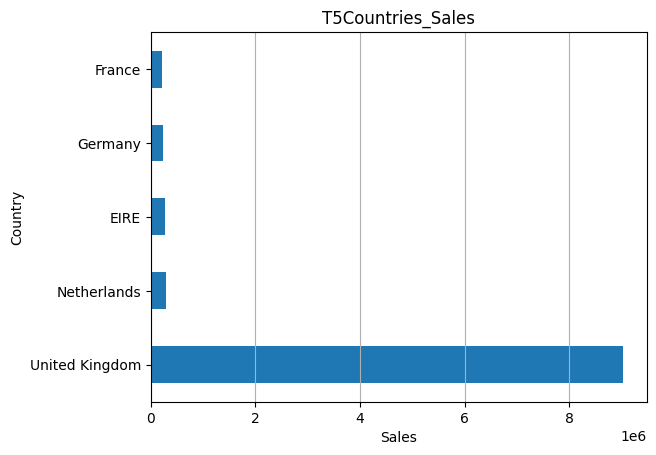

In [ ]:
T5Countries.plot(kind="barh",title="T5Countries_Sales",xlabel="Sales",ylabel="Country")
plt.grid(axis='x')
plt.show()

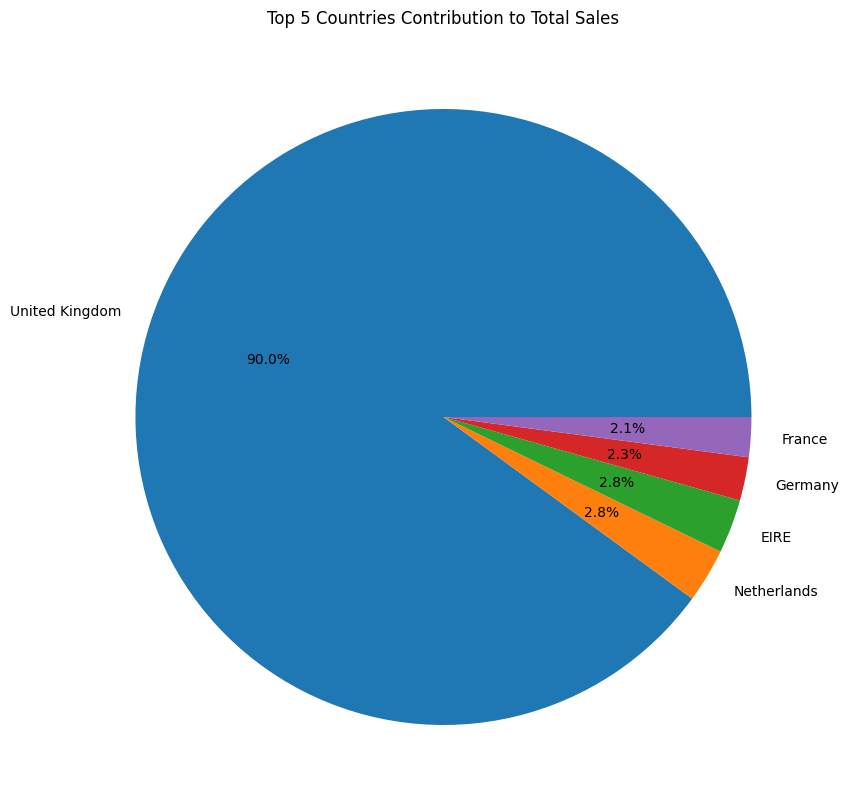

In [ ]:
AllCountries_Sales = df4.groupby("Country")["Total_Sales"].sum()
Total_Sales_Overall = AllCountries_Sales.sum()
Top5_Countries_Sales = AllCountries_Sales.sort_values(ascending=False).head(5)
Top5_Contribution = (Top5_Countries_Sales / Total_Sales_Overall) * 100

Top5_Contribution.plot(kind="pie", autopct="%1.1f%%", startangle=0, figsize=(10, 10), title="Top 5 Countries Contribution to Total Sales")
plt.ylabel("")
plt.show()

In [ ]:

# import pandas as pd
# from matplotlib import pyplot as plt

# # Load the data
# df1 = pd.read_excel("Online Retail.xlsx", dtype={'InvoiceNo': 'string', 'StockCode': 'string', 'Description': 'string', 'Country': 'string'})

# # Data Cleaning (Handling missing values and negative quantities/unit prices)
# Most_Freq = df1[["StockCode","Description"]].value_counts().reset_index().sort_values(["StockCode","Description"],ascending=[True,False]).drop_duplicates("StockCode")
# Most_Freq.columns = ["StockCode", "Freq_Des", "count"]
# df2 = df1.merge(Most_Freq, on="StockCode", how="left")
# df2.Description = df2.Freq_Des
# df2.dropna(subset=["Description"], inplace=True)
# df3 = df2[(df2.UnitPrice > 0) & (df2.Quantity > 0)].copy()

# # Feature Engineering (Calculate Total_Sales)
# df4 = df3.copy()
# df4["Total_Sales"] = df4.UnitPrice * df4.Quantity


# # Calculate and plot the top 5 countries' contribution
# AllCountries_Sales = df4.groupby("Country")["Total_Sales"].sum()
# Total_Sales_Overall = AllCountries_Sales.sum()
# Top5_Countries_Sales = AllCountries_Sales.sort_values(ascending=False).head(5)
# Top5_Contribution = (Top5_Countries_Sales / Total_Sales_Overall) * 100

# ax = Top5_Contribution.plot(kind="bar", figsize=(10, 6), title="Top 5 Countries Contribution to Total Sales")
# plt.ylabel("Percentage Contribution (%)")
# plt.xlabel("Country")
# plt.xticks(rotation=45, ha="right") # Rotate labels for better readability

# # Add percentage labels on top of bars
# for container in ax.containers:
#     ax.bar_label(container, fmt='%.01f%%')

# plt.tight_layout()
# plt.show()

In [ ]:
Most_Freq = df1[["StockCode","Description"]].value_counts().reset_index().sort_values(["StockCode","Description"],ascending=[True,False]).drop_duplicates("StockCode")
Most_Freq.tail(5)
# Most_Freq.columns = ["StockCode", "Freq_Des", "count"]
# df2 = df1.merge(Most_Freq, on="StockCode", how="left")
# df2.Description = df2.Freq_Des
# df2.dropna(subset=["Description"], inplace=True)
# df2

,StockCode,Description,count
4181,gift_0001_20,to push order througha s stock was,1
3432,gift_0001_30,Dotcomgiftshop Gift Voucher £30.00,7
3818,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,3
3694,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,4
4490,m,Manual,1


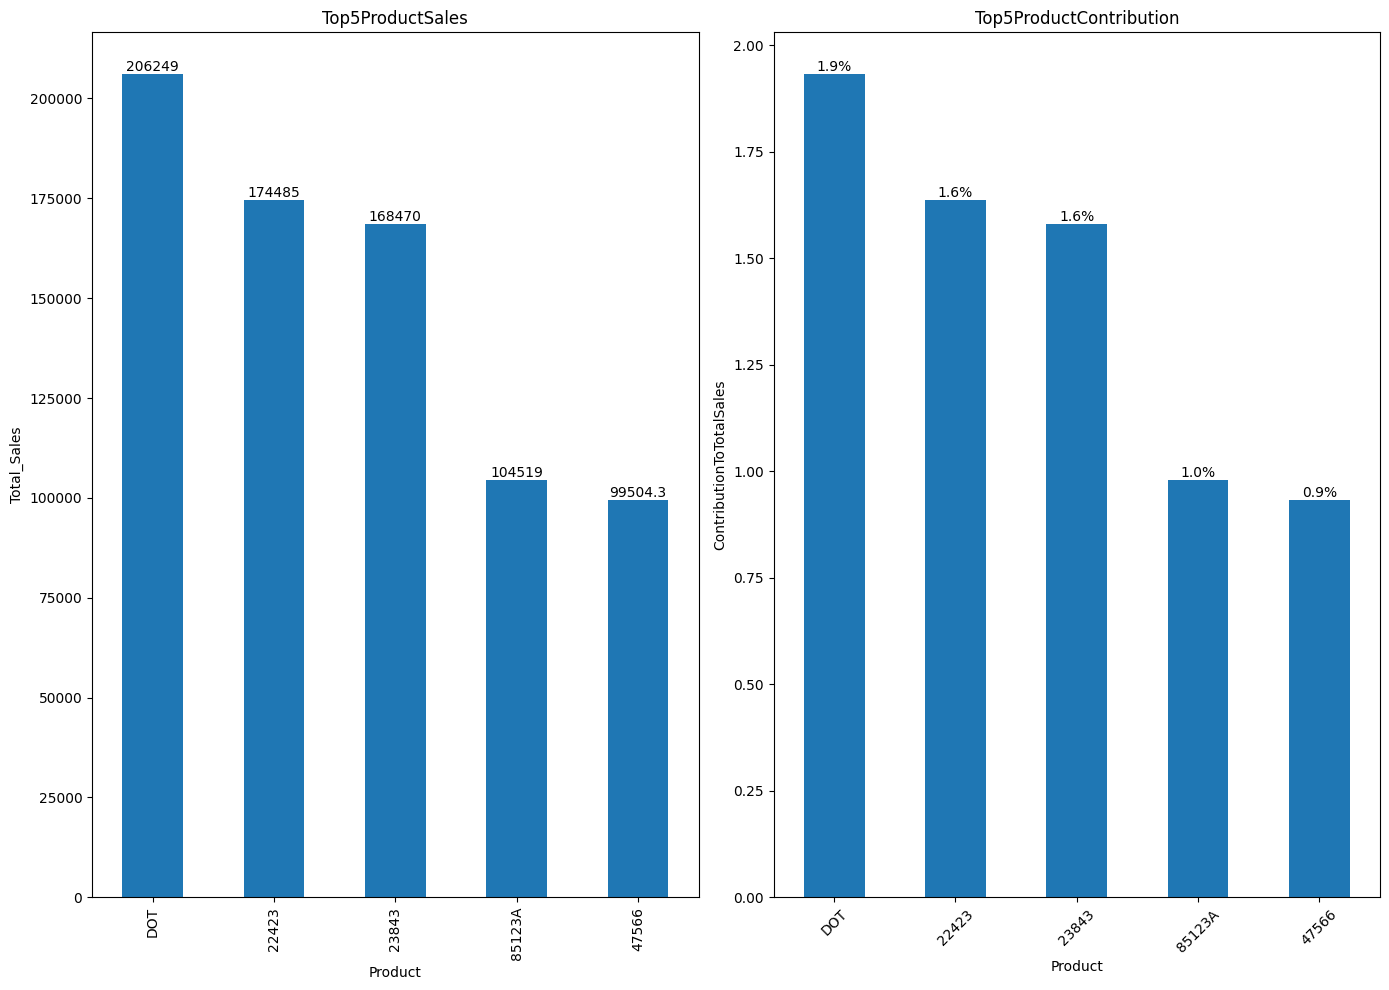

In [ ]:
AllProd_Sales=df4.groupby("StockCode")["Total_Sales"].sum().sum()

ProductWiseSales=df4.groupby("StockCode")["Total_Sales"].sum()
T5_Products=ProductWiseSales.sort_values(ascending=False).head(5)
T5_Productscontribution=(T5_Products/AllProd_Sales)*100



fig,ax=plt.subplots(nrows=1,ncols=2,figsize=(14,10))
T5_Products.plot(kind="bar",xlabel="Product",ylabel="Total_Sales",title="Top5ProductSales",ax=ax[0])
for container in ax[0].containers:
  ax[0].bar_label(container)

T5_Productscontribution.plot(kind="bar",xlabel="Product",ylabel="ContributionToTotalSales",title="Top5ProductContribution",ax=ax[1])
for container in ax[1].containers:
  ax[1].bar_label(container,fmt="%0.1f%%")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
for prods in T5_Products.index:
  des=df4[df4.StockCode==prods].Description.iloc[0]
  print(f"{prods} --> {des}")

DOT --> DOTCOM POSTAGE
22423 --> REGENCY CAKESTAND 3 TIER
23843 --> PAPER CRAFT , LITTLE BIRDIE
85123A --> WHITE HANGING HEART T-LIGHT HOLDER
47566 --> PARTY BUNTING


## RFM Analysis

In [ ]:
#Assume we are using live data, we want the data which is exactly the last's recorded day's next day
Current_DT=df4.InvoiceDate.max()+ pd.Timedelta(days=1)

In [ ]:
RFM=df4.groupby("CustomerID").agg({
    "InvoiceDate": lambda x:(Current_DT-x.max()).days,
    "InvoiceNo":'count',
    "Total_Sales":'sum'
})
RFM.columns=["Recency","Frequency","Monetary"]
RFM.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [ ]:
df4

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Total_Sales,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,12


In [ ]:
#Using Normal cut
RFM2=RFM.copy()
# intv,cat=RFM2.cut()
Ser,Int=pd.cut(RFM2["Recency"],bins=4,retbins=True)
print(Ser.head(5))
# print(Int)

CustomerID
12346.0    (280.75, 374.0]
12347.0     (0.627, 94.25]
12348.0     (0.627, 94.25]
12349.0     (0.627, 94.25]
12350.0    (280.75, 374.0]
Name: Recency, dtype: category
Categories (4, interval[float64, right]): [(0.627, 94.25] < (94.25, 187.5] < (187.5, 280.75] <
                                           (280.75, 374.0]]


In [ ]:
X,Y=pd.qcut(RFM["Recency"],q=4,retbins=True)
Y


array([  1.,  18.,  51., 142., 374.])

In [ ]:
# Segregating into different cuts


#Using quantile cut
RFM["R_CUT"]=pd.qcut(RFM["Recency"],q=4, labels=[4,3,2,1])
RFM["F_CUT"]=pd.qcut(RFM["Frequency"],q=4, labels=[1,2,3,4])
RFM["M_CUT"]=pd.qcut(RFM["Monetary"],q=4, labels=[1,2,3,4])
RFM["RFM_Score"]=RFM[["R_CUT","F_CUT","M_CUT"]].sum(axis=1)
RFM

,Recency,Frequency,Monetary,R_CUT,F_CUT,M_CUT,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,6
12347.0,2,182,4310.00,4,4,4,12
12348.0,75,31,1797.24,2,2,4,8
12349.0,19,73,1757.55,3,3,4,10
12350.0,310,17,334.40,1,1,2,4
...,...,...,...,...,...,...,...
18280.0,278,10,180.60,1,1,1,3
18281.0,181,7,80.82,1,1,1,3
18282.0,8,12,178.05,4,1,1,6


In [ ]:
RFM.sort_values("RFM_Score",ascending=False,inplace=True)

In [ ]:
RFM

,Recency,Frequency,Monetary,R_CUT,F_CUT,M_CUT,RFM_Score
CustomerID,,,,,,,
18198.0,4,159,5425.56,4,4,4,12
18210.0,2,134,2621.38,4,4,4,12
18225.0,3,271,5509.12,4,4,4,12
18283.0,4,756,2094.88,4,4,4,12
16983.0,13,148,1931.25,4,4,4,12
...,...,...,...,...,...,...,...
12402.0,323,11,225.60,1,1,1,3
18185.0,249,17,304.25,1,1,1,3
18190.0,192,15,284.46,1,1,1,3


### Churn Analysis

In [ ]:
churn_threshold=90
churnedcustomers=RFM.loc[RFM["Recency"]>90,["Recency"]]
churnedcustomers.sort_values("Recency",ascending=False)

#Here we can do some offers and things to try to get back these customers

,Recency
CustomerID,
16583.0,374
17968.0,374
13747.0,374
14729.0,374
17908.0,374
...,...
14414.0,92
15652.0,91
16723.0,91


Number of churned customer:  1449


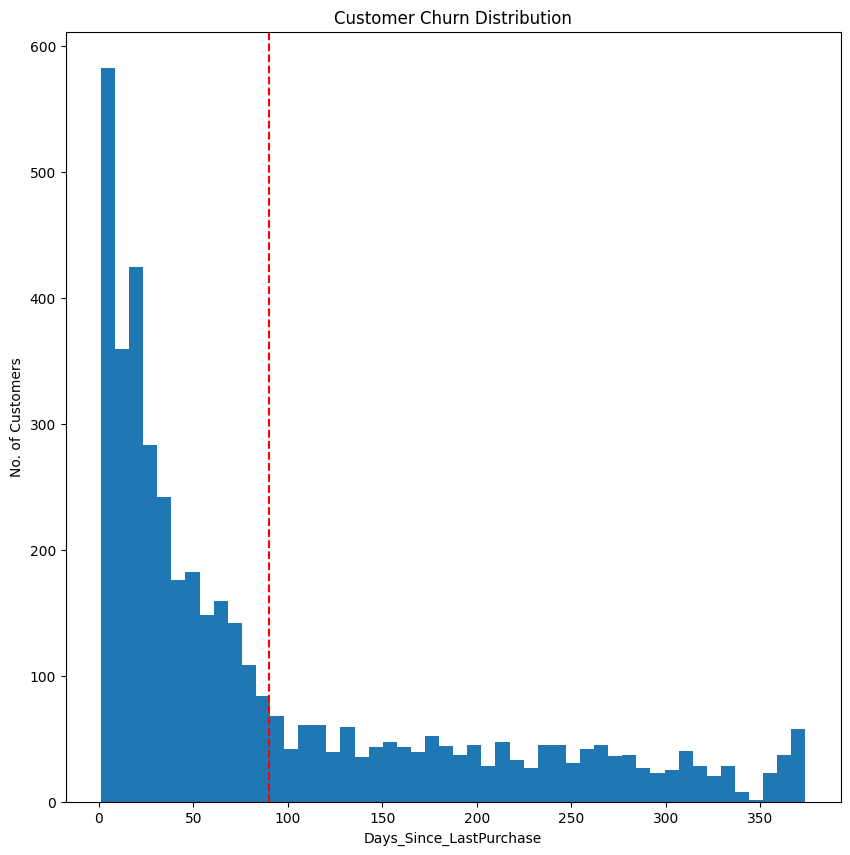

In [ ]:
print("Number of churned customer: ",len(churnedcustomers))


RFM['Recency'].plot(kind='hist',bins=50,xlabel="Days_Since_LastPurchase",ylabel="No. of Customers",figsize=(10,10))
plt.title("Customer Churn Distribution")
plt.axvline(churn_threshold,linestyle='dashed',color='red')
plt.show()

In [ ]:
TimeTaken=time.time()-startime
print(f"The library used is {pd.__name__}")
print("TimeElapsed with fireducks --> ",TimeTaken)

The library used is pandas
TimeElapsed with fireducks -->  66.66286993026733


The library used is pandas

TimeElapsed without fireducks -->  80.76774668693542